In [5]:
import numpy as np
import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def compute_promptness(df, sigma_t=0.2):

    t_min = pd.to_numeric(df["t_min"], errors="coerce").to_numpy(dtype=float)
    t_2min = pd.to_numeric(df["t_2min"], errors="coerce").to_numpy(dtype=float)
    t_3min = pd.to_numeric(df["t_3min"], errors="coerce").to_numpy(dtype=float)
    t_4min = pd.to_numeric(df["t_4min"], errors="coerce").to_numpy(dtype=float)
    t_5min = pd.to_numeric(df["t_5min"], errors="coerce").to_numpy(dtype=float)
    t_6min = pd.to_numeric(df["t_6min"], errors="coerce").to_numpy(dtype=float)
    t_7min = pd.to_numeric(df["t_7min"], errors="coerce").to_numpy(dtype=float)

    time_spread = np.nan_to_num((t_2min - t_min) / sigma_t, nan=0.0) + np.nan_to_num((t_3min - t_min) / sigma_t, nan=0.0) + np.nan_to_num((t_4min - t_min) / sigma_t, nan=0.0) + np.nan_to_num((t_5min - t_min) / sigma_t, nan=0.0) + np.nan_to_num((t_6min - t_min) / sigma_t, nan=0.0) + np.nan_to_num((t_7min - t_min) / sigma_t, nan=0.0)

    promptness = np.log(np.maximum(time_spread + 1, 1e-12))

    return promptness


def fisher_analysis(df, seed=18, test_size=0.3, min_st_dist=0, max_st_dist=600, pe_min=1, sigma_t=0.2):

    df_common = df.copy()

    df_common = df_common[df_common["T_C"] >= min_st_dist]
    df_common = df_common[df_common["T_C"] <= max_st_dist]
    df_common = df_common[df_common["total_pe"] >= pe_min]
    df_common = df_common.reset_index(drop=True)

    df_common["promptness"] = compute_promptness(df_common, sigma_t=sigma_t)

    feature_sets = {"8-inches": ["total_pe", "t_min"], "multiPMT_CA": ["total_pe", "chref_pe", "ch0_pe", "ch60_pe", "ch120_pe", "ch180_pe", "ch240_pe", "ch300_pe", "a_6ch"], "multiPMT_CATD": ["total_pe", "t_ref0", "t_ref60", "t_ref120", "t_ref180", "t_ref240", "t_ref300", "tref", "t_min", "t_2min", "t_3min", "t_4min", "t_5min", "t_6min", "t_7min", "chref_pe", "ch0_pe", "ch60_pe", "ch120_pe", "ch180_pe", "ch240_pe", "ch300_pe", "a_6ch", "promptness"]}

    all_features = list(dict.fromkeys(feature for feature_list in feature_sets.values() for feature in feature_list))

    missing_features = [feature for feature in all_features if feature not in df_common.columns]

    if missing_features:
        raise KeyError(f"Missing variables: {missing_features}")

    df_common[all_features] = df_common[all_features].apply(pd.to_numeric, errors="coerce")
    df_common[all_features] = df_common[all_features].replace([np.inf, -np.inf], np.nan)

    print("Events before imputation:", len(df_common))
    print("Events containing at least one missing value:", df_common[all_features].isna().any(axis=1).sum())
    print(df_common["IsThereMuon"].value_counts())

    y = df_common["IsThereMuon"].to_numpy(dtype=int)
    indices = np.arange(len(df_common))

    train_indices, test_indices = train_test_split(indices, test_size=test_size, random_state=seed, stratify=y)

    y_train = y[train_indices]
    y_test = y[test_indices]

    results = {}
    summary = []

    for model_name, features in feature_sets.items():

        X = df_common[features].to_numpy(dtype=float)

        X_train = X[train_indices]
        X_test = X[test_indices]

        missing_train = np.isnan(X_train).any(axis=1)
        missing_test = np.isnan(X_test).any(axis=1)

        imputer = SimpleImputer(strategy="median")
        X_train_imputed = imputer.fit_transform(X_train)
        X_test_imputed = imputer.transform(X_test)

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_imputed)
        X_test_scaled = scaler.transform(X_test_imputed)

        fisher = LinearDiscriminantAnalysis(solver="lsqr", store_covariance=True)
        fisher.fit(X_train_scaled, y_train)

        fisher_score = fisher.decision_function(X_test_scaled)
        auc_value = roc_auc_score(y_test, fisher_score)
        fpr, tpr, thresholds = roc_curve(y_test, fisher_score)

        coefficients = pd.Series(fisher.coef_[0], index=features)

        results[model_name] = {"model": fisher, "imputer": imputer, "scaler": scaler, "features": features, "X_test_scaled": X_test_scaled, "score": fisher_score, "auc": auc_value, "fpr": fpr, "tpr": tpr, "thresholds": thresholds, "coefficients": coefficients}

        summary.append({"model": model_name, "n_features": len(features), "n_train": len(train_indices), "n_test": len(test_indices), "imputed_train": missing_train.sum(), "imputed_test": missing_test.sum(), "auc": auc_value})

        print(f"\n{model_name}")
        print("Priors inferred from training:", fisher.priors_)
        print(f"Training events containing imputed values = {missing_train.sum()}")
        print(f"Testing events containing imputed values = {missing_test.sum()}")
        print(f"ROC AUC = {auc_value:.4f}")
        print("Standardized Fisher coefficients:")
        print(coefficients.sort_values(key=np.abs, ascending=False))

    summary = pd.DataFrame(summary)

    print("\nComparison:")
    print(summary)

    return results, summary, df_common, train_indices, test_indices, y

In [6]:
import pandas as pd
from pathlib import Path
from py_code import config_loader

conf = config_loader.load_config("config.yaml")

PROJECT_DIR = Path.cwd().parent

train_path = Path(f"{PROJECT_DIR}/{conf['feats_dir']}/{conf['array_dir']}/train/sm_bkg/{conf['params_dir']}/{conf['features_cut_dir']}/df_{conf['mpmt_or_8inches']}_{conf['ADC_dir']}_{conf['intended_cut_on_pes']}bkg{conf['intended_cut_on_pes']}smu_pe.parquet")

df = pd.read_parquet(train_path)

results, summary, df_common, train_indices, test_indices, y = fisher_analysis(df, seed=18, test_size=0.3, min_st_dist=conf["train_min_st_dist"], max_st_dist=conf["train_max_st_dist"], pe_min=conf["train_pe_min"], sigma_t=0.2)

Events before imputation: 444664
Events containing at least one missing value: 216864
IsThereMuon
0    378649
1     66015
Name: count, dtype: int64

8-inches
Priors inferred from training: [0.85154081 0.14845919]
Training events containing imputed values = 0
Testing events containing imputed values = 0
ROC AUC = 0.6721
Standardized Fisher coefficients:
t_min       0.740722
total_pe   -0.061779
dtype: float64

multiPMT_CA
Priors inferred from training: [0.85154081 0.14845919]
Training events containing imputed values = 5
Testing events containing imputed values = 2
ROC AUC = 0.7906
Standardized Fisher coefficients:
total_pe   -2.201793
a_6ch       1.167638
ch0_pe      0.559427
ch120_pe    0.452327
ch240_pe    0.318413
chref_pe    0.312688
ch300_pe    0.270632
ch60_pe     0.200508
ch180_pe    0.109102
dtype: float64

multiPMT_CATD
Priors inferred from training: [0.85154081 0.14845919]
Training events containing imputed values = 151589
Testing events containing imputed values = 65275
ROC 

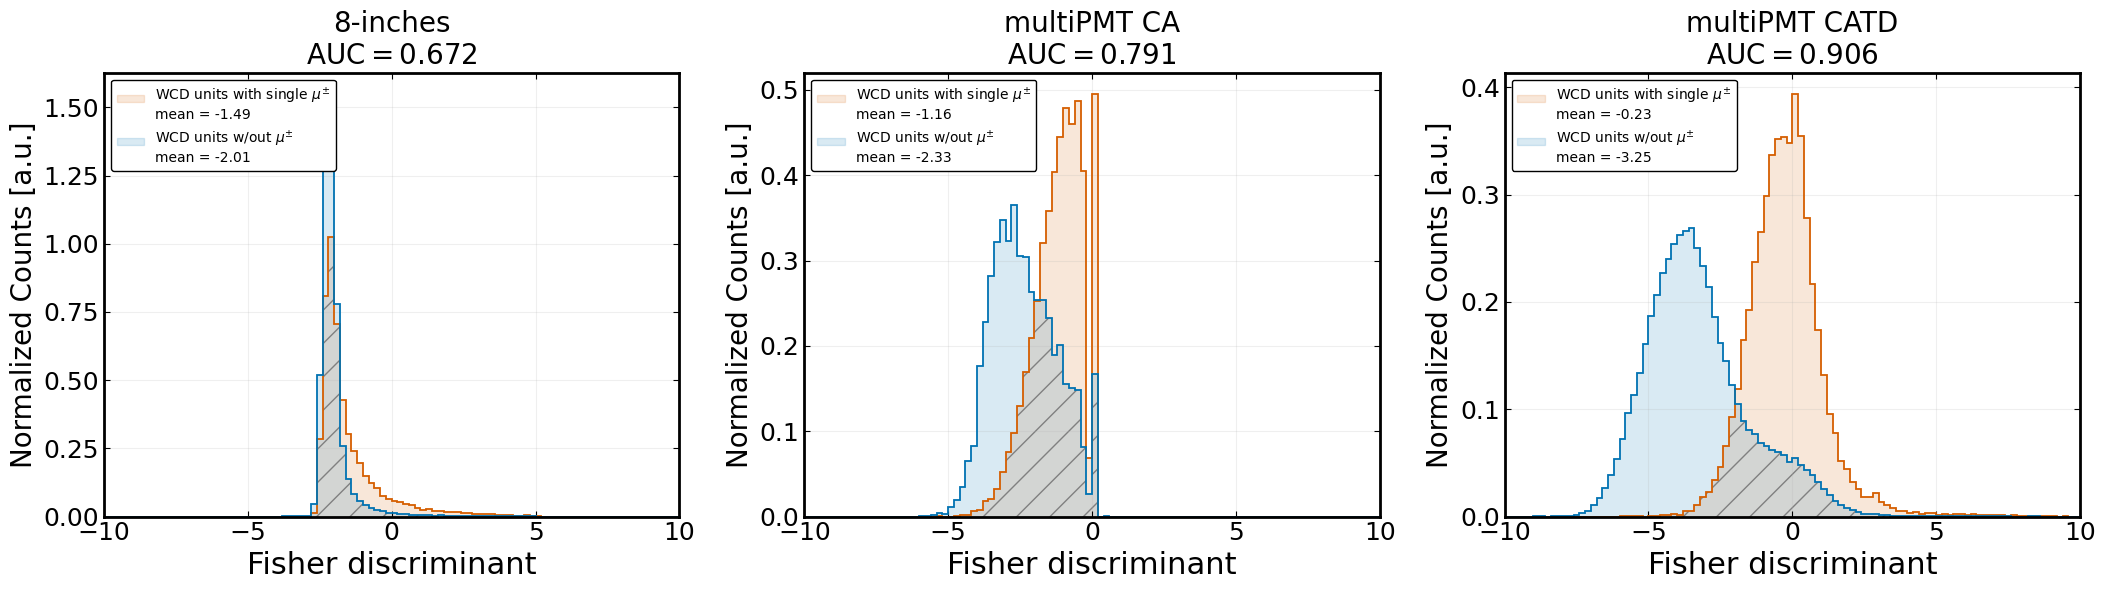

In [7]:
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

class OffsetHandler(HandlerBase):

    def __init__(self, x_offset=0, y_offset=0, **kwargs):
        self.x_offset = x_offset
        self.y_offset = y_offset
        super().__init__(**kwargs)

    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        patch = Rectangle((0, 0), width, height, facecolor=orig_handle.get_facecolor(), edgecolor=orig_handle.get_edgecolor(), linewidth=orig_handle.get_linewidth())
        patch.set_transform(trans + mtransforms.Affine2D().translate(self.x_offset, self.y_offset))
        return [patch]


mu_color = "#D55E00"
nomu_color = "#0072B2"

fig, axes = plt.subplots(1, len(results), figsize=(7 * len(results), 6))

axes = np.atleast_1d(axes)
y_test_common = np.asarray(y[test_indices])

for ax, (model_name, result) in zip(axes, results.items()):

    fisher_score = np.asarray(result["score"])

    score_mu = fisher_score[y_test_common == 1]
    score_nomu = fisher_score[y_test_common == 0]

    score_mu = score_mu[np.isfinite(score_mu)]
    score_nomu = score_nomu[np.isfinite(score_nomu)]

    bins = 100
    range_hist = (-10, 10)

    counts_mu, bin_edges = np.histogram(score_mu, bins=bins, range=range_hist, density=True)
    counts_nomu, _ = np.histogram(score_nomu, bins=bins, range=range_hist, density=True)

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]
    overlap = np.minimum(counts_mu, counts_nomu)

    mean_mu = np.mean(score_mu)
    mean_nomu = np.mean(score_nomu)

    ax.hist(score_mu, density=True, bins=bins, range=range_hist, histtype="stepfilled", color=mu_color, alpha=0.15)
    ax.hist(score_mu, density=True, bins=bins, range=range_hist, histtype="step", color=mu_color, linewidth=1.3)

    ax.hist(score_nomu, density=True, bins=bins, range=range_hist, histtype="stepfilled", color=nomu_color, alpha=0.15)
    ax.hist(score_nomu, density=True, bins=bins, range=range_hist, histtype="step", color=nomu_color, linewidth=1.3)

    ax.bar(bin_centers, overlap, width=bin_width, color="none", edgecolor="gray", hatch="/", linewidth=0)

    handles = [Rectangle((0, 0), 1, 1, facecolor=mu_color, edgecolor=mu_color, linewidth=1, alpha=0.15), Rectangle((0, 0), 1, 1, facecolor=nomu_color, edgecolor=nomu_color, linewidth=1, alpha=0.15)]

    labels = [rf"WCD units with single $\mu^{{\pm}}$" + "\n" + rf"mean = {mean_mu:.2f}", rf"WCD units w/out $\mu^{{\pm}}$" + "\n" + rf"mean = {mean_nomu:.2f}"]

    ax.set_title(model_name.replace("_", " ") + "\n" + rf"$\mathrm{{AUC}}={result['auc']:.3f}$", fontsize=20)
    ax.set_xlabel("Fisher discriminant", fontsize=22)
    ax.set_ylabel("Normalized Counts [a.u.]", fontsize=20)

    ax.set_xlim(range_hist)

    ax.tick_params(axis="both", which="major", direction="in", top=True, right=True, labelsize=18, length=4)
    ax.minorticks_off()
    ax.grid(True, alpha=0.2)

    for spine in ax.spines.values():
        spine.set_linewidth(2)

    ax.legend(handles=handles, labels=labels, handler_map={Rectangle: OffsetHandler(x_offset=0, y_offset=7)}, loc="upper left", edgecolor="black", handleheight=0.4, facecolor="white", framealpha=1.0, fontsize=10)

plt.tight_layout()
plt.show()

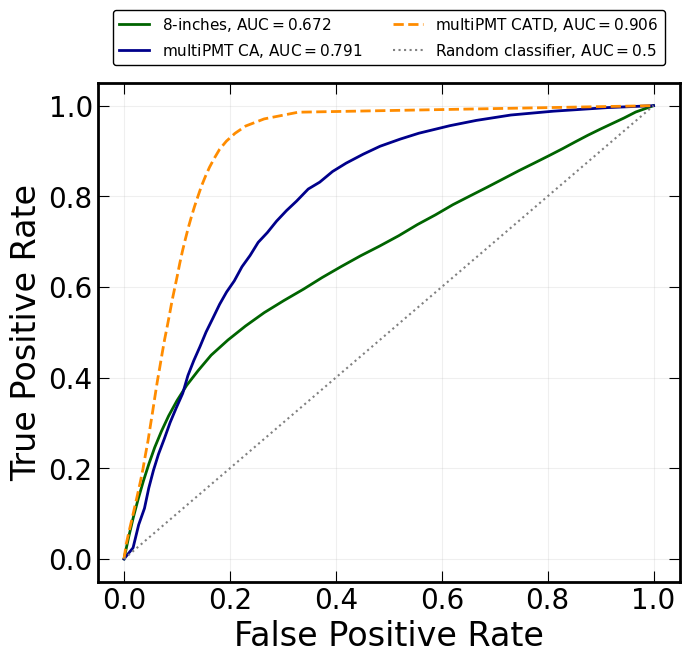

In [8]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

colors = ["darkgreen", "darkblue", "darkorange"]
linestyles = ["-", "-", "--"]

for (model_name, result), color, linestyle in zip(results.items(), colors, linestyles):

    fpr = np.asarray(result["fpr"])
    tpr = np.asarray(result["tpr"])
    auc_value = result["auc"]

    n_points = 40
    plot_indices = np.unique(np.linspace(0, len(fpr) - 1, min(n_points, len(fpr)), dtype=int))

    plt.plot(fpr[plot_indices], tpr[plot_indices], color=color, linestyle=linestyle, linewidth=2, label=rf"{model_name.replace('_', ' ')}, $\mathrm{{AUC}}={auc_value:.3f}$")

plt.plot([0, 1], [0, 1], color="gray", linestyle=":", linewidth=1.5, label=r"Random classifier, $\mathrm{AUC}=0.5$")

plt.xlabel("False Positive Rate", fontsize=24)
plt.ylabel("True Positive Rate", fontsize=24)

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

plt.tick_params(axis="both", which="major", direction="in", top=True, right=True, labelsize=20, length=8)

plt.minorticks_off()
plt.grid(True, alpha=0.2)

for spine in plt.gca().spines.values():
    spine.set_linewidth(2)

plt.tight_layout()

legend = plt.legend(frameon=True, fontsize=11, facecolor="white", framealpha=1.0, edgecolor="black", loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2)

plt.show()

In [9]:
print("Dataset path:", train_path)
print("Dataset shape:", df.shape)
print("Number of events:", len(df))
print("Number of features:", len(df.columns))
print("Columns:", df.columns.tolist())
print("\nClass distribution:")
print(df["IsThereMuon"].value_counts())
print("\nClass fractions:")
print(df["IsThereMuon"].value_counts(normalize=True))

Dataset path: /home/grieco/SWGO_Soft/git_GH_multiPMT/working_branch/multiPMT_GammaHadron_ML/dfs_feats/mPMT_HAWCSim_array/train/sm_bkg/100300TeV_030deg_4FF_180R175h_Black/NoneMHz_ADC_13petrain_13petest_500ns/df_mPMT_NoneMHz_ADC_13bkg13smu_pe.parquet
Dataset shape: (446518, 46)
Number of events: 446518
Number of features: 46
Columns: ['t0', 'tref', 't60', 't120', 't180', 't240', 't300', 'T_C', 'IsThereMuon', 't_ref0', 't_ref60', 't_ref120', 't_ref180', 't_ref240', 't_ref300', 'multiplicity', 'total_pe', 'a_time_2ch', 'a_time_6ch', 't_min', 't_2min', 't_3min', 't_4min', 't_5min', 't_6min', 't_7min', 'ch0_pe', 'chref_pe', 'ch60_pe', 'ch120_pe', 'ch180_pe', 'ch240_pe', 'ch300_pe', 'norm_ch0_pe', 'norm_chref_pe', 'norm_ch60_pe', 'norm_ch120_pe', 'norm_ch180_pe', 'norm_ch240_pe', 'norm_ch300_pe', 'var', 'r_bar', 'a_6ch', 'a_4ch', 'a_2ch', 'a_dyn']

Class distribution:
IsThereMuon
0    379504
1     67014
Name: count, dtype: int64

Class fractions:
IsThereMuon
0    0.849919
1    0.150081
Name: 

In [22]:
import optuna
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.metrics import auc, precision_recall_curve, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

excluded_columns = ["IsThereMuon", "frac_mu", "ch_0", "ch_ref", "ch_60", "ch_120", "ch_180", "ch_240", "ch_300"]

all_possible_features = df_common.drop(columns=excluded_columns, errors="ignore").select_dtypes(include=np.number).columns.tolist()

feature_sets = {"8-inches": ["total_pe", "t_min", "T_C"], "multiPMT_CA": ["total_pe", "T_C", "chref_pe", "ch0_pe", "ch60_pe", "ch120_pe", "ch180_pe", "ch240_pe", "ch300_pe", "a_6ch"], "multiPMT_CATD": ["total_pe", "T_C", "t_ref0", "t_ref60", "t_ref120", "t_ref180", "t_ref240", "t_ref300", "tref", "t_min", "t_2min", "t_3min", "t_4min", "t_5min", "t_6min", "t_7min", "chref_pe", "ch0_pe", "ch60_pe", "ch120_pe", "ch180_pe", "ch240_pe", "ch300_pe", "a_6ch", "promptness"], "multiPMT_ALL": all_possible_features}

for model_name, features in feature_sets.items():
    print(f"\n{model_name}: {len(features)} variables")
    print(features)
    
def xgb_objective(trial, X, y, seed):

    scale_pos_weight = np.sum(y == 0) / np.sum(y == 1)

    params = {"n_estimators": trial.suggest_int("n_estimators", 100, 1000), "max_depth": trial.suggest_int("max_depth", 3, 6), "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True), "subsample": trial.suggest_float("subsample", 0.6, 1.0), "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0), "min_child_weight": trial.suggest_int("min_child_weight", 2, 3), "scale_pos_weight": scale_pos_weight, "eval_metric": "aucpr", "random_state": seed}

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    pr_aucs = []

    for train_fold, validation_fold in cv.split(X, y):

        pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("model", XGBClassifier(**params))])

        pipeline.fit(X.iloc[train_fold], y.iloc[train_fold])

        probability = pipeline.predict_proba(X.iloc[validation_fold])[:, 1]

        precision, recall, _ = precision_recall_curve(y.iloc[validation_fold], probability)

        pr_aucs.append(auc(recall, precision))

    return np.mean(pr_aucs)


def optimize_xgb(X, y, seed=18, n_trials=15):

    optuna.logging.set_verbosity(optuna.logging.ERROR)

    study = optuna.create_study(direction="maximize")
    study.optimize(lambda trial: xgb_objective(trial, X, y, seed), n_trials=n_trials, show_progress_bar=True)

    best_params = study.best_params

    best_params.update({"scale_pos_weight": np.sum(y == 0) / np.sum(y == 1), "eval_metric": "aucpr", "random_state": seed})

    return best_params


xgb_results = {}
xgb_summary = []

y_train_xgb = pd.Series(y[train_indices]).reset_index(drop=True)
y_test_xgb = np.asarray(y[test_indices])

for model_name, features in feature_sets.items():

    X_train_xgb = df_common.iloc[train_indices][features].reset_index(drop=True)
    X_test_xgb = df_common.iloc[test_indices][features].reset_index(drop=True)

    best_params = optimize_xgb(X_train_xgb, y_train_xgb, seed=18, n_trials=15)

    pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("model", XGBClassifier(**best_params))])

    pipeline.fit(X_train_xgb, y_train_xgb)

    xgb_score = pipeline.predict_proba(X_test_xgb)[:, 1]

    roc_auc_value = roc_auc_score(y_test_xgb, xgb_score)
    fpr, tpr, thresholds = roc_curve(y_test_xgb, xgb_score)

    precision, recall, pr_thresholds = precision_recall_curve(y_test_xgb, xgb_score)
    pr_auc_value = auc(recall, precision)

    xgb_results[model_name] = {"model": pipeline, "features": features, "score": xgb_score, "roc_auc": roc_auc_value, "pr_auc": pr_auc_value, "fpr": fpr, "tpr": tpr, "thresholds": thresholds, "precision": precision, "recall": recall, "pr_thresholds": pr_thresholds, "best_params": best_params}

    xgb_summary.append({"model": model_name, "n_features": len(features), "n_train": len(train_indices), "n_test": len(test_indices), "roc_auc": roc_auc_value, "pr_auc": pr_auc_value})

    print(f"\n{model_name}")
    print(f"ROC AUC = {roc_auc_value:.4f}")
    print(f"PR AUC = {pr_auc_value:.4f}")
    print("Best parameters:")
    print(best_params)

xgb_summary = pd.DataFrame(xgb_summary)

print("\nXGBoost comparison:")
display(xgb_summary)


8-inches: 3 variables
['total_pe', 't_min', 'T_C']

multiPMT_CA: 10 variables
['total_pe', 'T_C', 'chref_pe', 'ch0_pe', 'ch60_pe', 'ch120_pe', 'ch180_pe', 'ch240_pe', 'ch300_pe', 'a_6ch']

multiPMT_CATD: 25 variables
['total_pe', 'T_C', 't_ref0', 't_ref60', 't_ref120', 't_ref180', 't_ref240', 't_ref300', 'tref', 't_min', 't_2min', 't_3min', 't_4min', 't_5min', 't_6min', 't_7min', 'chref_pe', 'ch0_pe', 'ch60_pe', 'ch120_pe', 'ch180_pe', 'ch240_pe', 'ch300_pe', 'a_6ch', 'promptness']

multiPMT_ALL: 46 variables
['t0', 'tref', 't60', 't120', 't180', 't240', 't300', 'T_C', 't_ref0', 't_ref60', 't_ref120', 't_ref180', 't_ref240', 't_ref300', 'multiplicity', 'total_pe', 'a_time_2ch', 'a_time_6ch', 't_min', 't_2min', 't_3min', 't_4min', 't_5min', 't_6min', 't_7min', 'ch0_pe', 'chref_pe', 'ch60_pe', 'ch120_pe', 'ch180_pe', 'ch240_pe', 'ch300_pe', 'norm_ch0_pe', 'norm_chref_pe', 'norm_ch60_pe', 'norm_ch120_pe', 'norm_ch180_pe', 'norm_ch240_pe', 'norm_ch300_pe', 'var', 'r_bar', 'a_6ch', 'a_4ch'

  0%|          | 0/15 [00:00<?, ?it/s]


8-inches
ROC AUC = 0.8533
PR AUC = 0.6259
Best parameters:
{'n_estimators': 460, 'max_depth': 5, 'learning_rate': 0.04616338294349604, 'subsample': 0.6834540954072191, 'colsample_bytree': 0.7754495600794837, 'min_child_weight': 3, 'scale_pos_weight': np.float64(5.735858039385414), 'eval_metric': 'aucpr', 'random_state': 18}


  0%|          | 0/15 [00:00<?, ?it/s]


multiPMT_CA
ROC AUC = 0.9211
PR AUC = 0.7122
Best parameters:
{'n_estimators': 1000, 'max_depth': 4, 'learning_rate': 0.09530871355882717, 'subsample': 0.9882862247361192, 'colsample_bytree': 0.8925646124585888, 'min_child_weight': 2, 'scale_pos_weight': np.float64(5.735858039385414), 'eval_metric': 'aucpr', 'random_state': 18}


  0%|          | 0/15 [00:00<?, ?it/s]


multiPMT_CATD
ROC AUC = 0.9713
PR AUC = 0.8536
Best parameters:
{'n_estimators': 127, 'max_depth': 5, 'learning_rate': 0.07474590891174725, 'subsample': 0.7809972075982154, 'colsample_bytree': 0.6035508116544426, 'min_child_weight': 3, 'scale_pos_weight': np.float64(5.735858039385414), 'eval_metric': 'aucpr', 'random_state': 18}


  0%|          | 0/15 [00:00<?, ?it/s]


multiPMT_ALL
ROC AUC = 0.9796
PR AUC = 0.8915
Best parameters:
{'n_estimators': 957, 'max_depth': 5, 'learning_rate': 0.05467145403226289, 'subsample': 0.8817386637245777, 'colsample_bytree': 0.9359452669368686, 'min_child_weight': 2, 'scale_pos_weight': np.float64(5.735858039385414), 'eval_metric': 'aucpr', 'random_state': 18}

XGBoost comparison:


,model,n_features,n_train,n_test,roc_auc,pr_auc
0,8-inches,3,311264,133400,0.853319,0.625888
1,multiPMT_CA,10,311264,133400,0.921080,0.712209
2,multiPMT_CATD,25,311264,133400,0.971264,0.853625
3,multiPMT_ALL,46,311264,133400,0.979621,0.891533


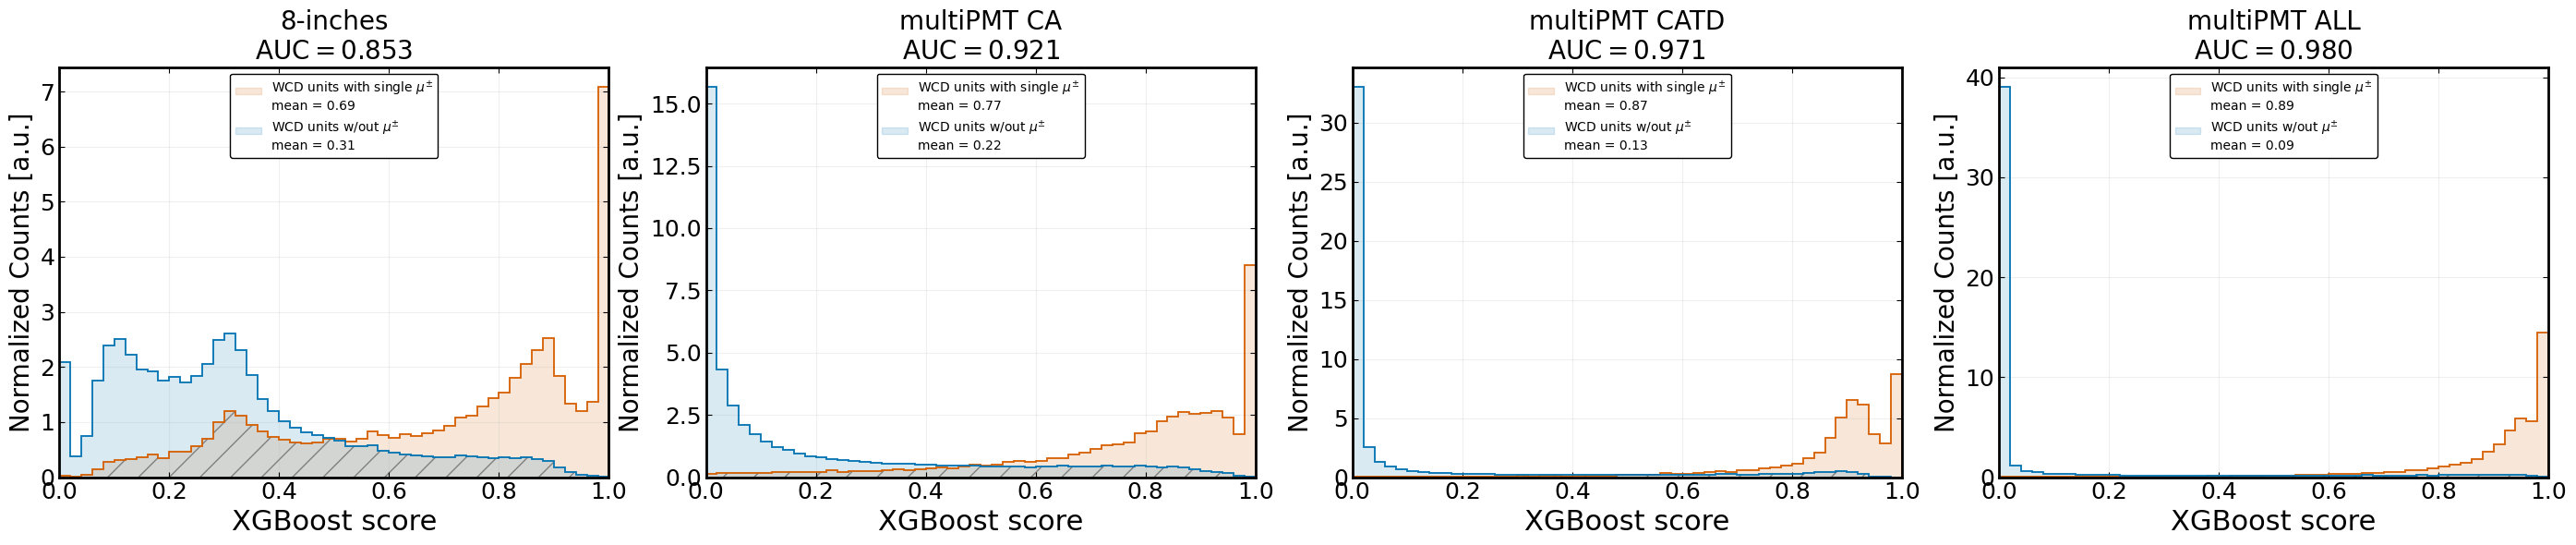

In [23]:
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

class OffsetHandler(HandlerBase):

    def __init__(self, x_offset=0, y_offset=0, **kwargs):
        self.x_offset = x_offset
        self.y_offset = y_offset
        super().__init__(**kwargs)

    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        patch = Rectangle((0, 0), width, height, facecolor=orig_handle.get_facecolor(), edgecolor=orig_handle.get_edgecolor(), linewidth=orig_handle.get_linewidth())
        patch.set_transform(trans + mtransforms.Affine2D().translate(self.x_offset, self.y_offset))
        return [patch]


mu_color = "#D55E00"
nomu_color = "#0072B2"

fig, axes = plt.subplots(1, len(xgb_results), figsize=(7 * len(xgb_results), 6))

axes = np.atleast_1d(axes)

for ax, (model_name, result) in zip(axes, xgb_results.items()):

    xgb_score = np.asarray(result["score"])

    score_mu = xgb_score[y_test_xgb == 1]
    score_nomu = xgb_score[y_test_xgb == 0]

    score_mu = score_mu[np.isfinite(score_mu)]
    score_nomu = score_nomu[np.isfinite(score_nomu)]

    bins = 50
    range_hist = (0, 1)

    counts_mu, bin_edges = np.histogram(score_mu, bins=bins, range=range_hist, density=True)
    counts_nomu, _ = np.histogram(score_nomu, bins=bins, range=range_hist, density=True)

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]
    overlap = np.minimum(counts_mu, counts_nomu)

    mean_mu = np.mean(score_mu)
    mean_nomu = np.mean(score_nomu)

    ax.hist(score_mu, density=True, bins=bins, range=range_hist, histtype="stepfilled", color=mu_color, alpha=0.15)
    ax.hist(score_mu, density=True, bins=bins, range=range_hist, histtype="step", color=mu_color, linewidth=1.3)

    ax.hist(score_nomu, density=True, bins=bins, range=range_hist, histtype="stepfilled", color=nomu_color, alpha=0.15)
    ax.hist(score_nomu, density=True, bins=bins, range=range_hist, histtype="step", color=nomu_color, linewidth=1.3)

    ax.bar(bin_centers, overlap, width=bin_width, color="none", edgecolor="gray", hatch="/", linewidth=0)

    handles = [Rectangle((0, 0), 1, 1, facecolor=mu_color, edgecolor=mu_color, linewidth=1, alpha=0.15), Rectangle((0, 0), 1, 1, facecolor=nomu_color, edgecolor=nomu_color, linewidth=1, alpha=0.15)]

    labels = [rf"WCD units with single $\mu^{{\pm}}$" + "\n" + rf"mean = {mean_mu:.2f}", rf"WCD units w/out $\mu^{{\pm}}$" + "\n" + rf"mean = {mean_nomu:.2f}"]

    ax.set_title(model_name.replace("_", " ") + "\n" + rf"$\mathrm{{AUC}}={result['roc_auc']:.3f}$", fontsize=20)
    ax.set_xlabel("XGBoost score", fontsize=22)
    ax.set_ylabel("Normalized Counts [a.u.]", fontsize=20)

    ax.set_xlim(range_hist)

    ax.tick_params(axis="both", which="major", direction="in", top=True, right=True, labelsize=18, length=4)
    ax.minorticks_off()
    ax.grid(True, alpha=0.2)

    for spine in ax.spines.values():
        spine.set_linewidth(2)

    ax.legend(handles=handles, labels=labels, handler_map={Rectangle: OffsetHandler(x_offset=0, y_offset=7)}, loc="upper center", edgecolor="black", handleheight=0.4, facecolor="white", framealpha=1.0, fontsize=10)

plt.tight_layout()
plt.show()

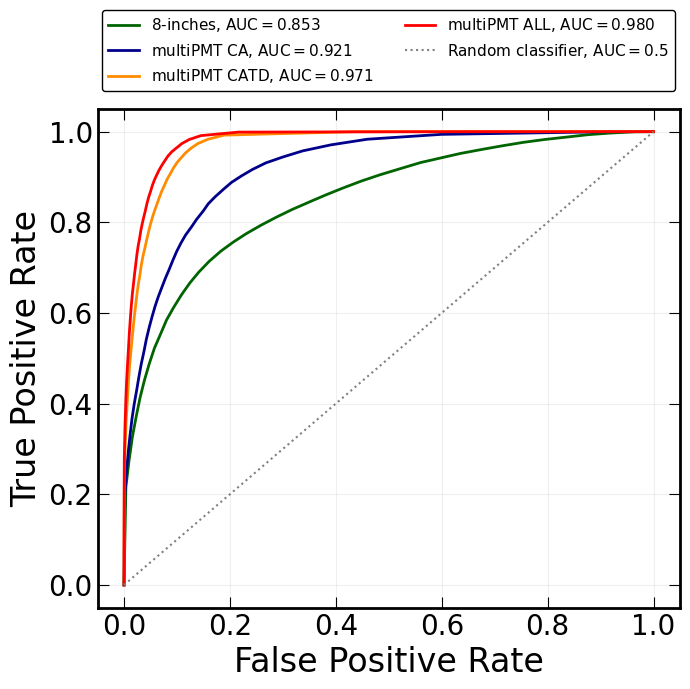

In [25]:
plt.figure(figsize=(7, 6))

colors = ["darkgreen", "darkblue", "darkorange", "red"]
linestyles = ["-", "-", "-", "-"]

for (model_name, result), color, linestyle in zip(xgb_results.items(), colors, linestyles):

    fpr = np.asarray(result["fpr"])
    tpr = np.asarray(result["tpr"])
    roc_auc_value = result["roc_auc"]

    n_points = 40
    plot_indices = np.unique(np.linspace(0, len(fpr) - 1, min(n_points, len(fpr)), dtype=int))

    plt.plot(fpr[plot_indices], tpr[plot_indices], color=color, linestyle=linestyle, linewidth=2, label=rf"{model_name.replace('_', ' ')}, $\mathrm{{AUC}}={roc_auc_value:.3f}$")

plt.plot([0, 1], [0, 1], color="gray", linestyle=":", linewidth=1.5, label=r"Random classifier, $\mathrm{AUC}=0.5$")

plt.xlabel("False Positive Rate", fontsize=24)
plt.ylabel("True Positive Rate", fontsize=24)

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

plt.tick_params(axis="both", which="major", direction="in", top=True, right=True, labelsize=20, length=8)

plt.minorticks_off()
plt.grid(True, alpha=0.2)

for spine in plt.gca().spines.values():
    spine.set_linewidth(2)

plt.tight_layout()

legend = plt.legend(frameon=True, fontsize=11, facecolor="white", framealpha=1.0, edgecolor="black", loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2)

plt.show()

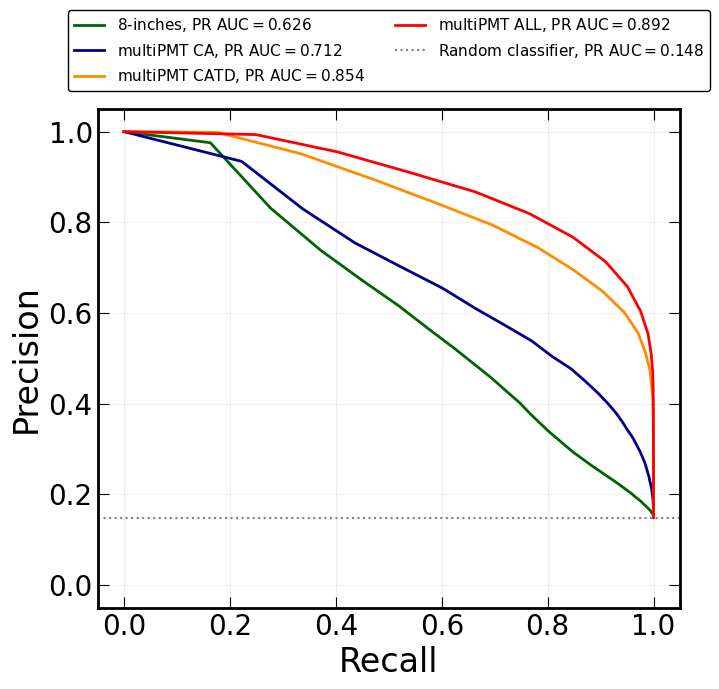

In [26]:
plt.figure(figsize=(7, 6))

colors = ["darkgreen", "darkblue", "darkorange", "red"]
linestyles = ["-", "-", "-", "-"]

for (model_name, result), color, linestyle in zip(xgb_results.items(), colors, linestyles):

    precision = np.asarray(result["precision"])
    recall = np.asarray(result["recall"])
    pr_auc_value = result["pr_auc"]

    n_points = 40
    plot_indices = np.unique(np.linspace(0, len(recall) - 1, min(n_points, len(recall)), dtype=int))

    plt.plot(recall[plot_indices], precision[plot_indices], color=color, linestyle=linestyle, linewidth=2, label=rf"{model_name.replace('_', ' ')}, $\mathrm{{PR\ AUC}}={pr_auc_value:.3f}$")

pr_baseline = np.mean(y_test_xgb == 1)

plt.axhline(pr_baseline, color="gray", linestyle=":", linewidth=1.5, label=rf"Random classifier, $\mathrm{{PR\ AUC}}={pr_baseline:.3f}$")

plt.xlabel("Recall", fontsize=24)
plt.ylabel("Precision", fontsize=24)

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

plt.tick_params(axis="both", which="major", direction="in", top=True, right=True, labelsize=20, length=8)

plt.minorticks_off()
plt.grid(True, alpha=0.2)

for spine in plt.gca().spines.values():
    spine.set_linewidth(2)

plt.tight_layout()

legend = plt.legend(frameon=True, fontsize=11, facecolor="white", framealpha=1.0, edgecolor="black", loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2)

plt.show()

In [27]:
time_columns = ["t_min", "t_2min", "t_3min", "t_4min", "t_5min", "t_6min", "t_7min", "tref", "t_ref0", "t_ref60", "t_ref120", "t_ref180", "t_ref240", "t_ref300"]

time_resolution = 0.2
tolerance = 1e-8

for column in time_columns:

    values = pd.to_numeric(df_common[column], errors="coerce").to_numpy(dtype=float)
    finite_values = values[np.isfinite(values)]

    on_grid = np.isclose(finite_values / time_resolution, np.rint(finite_values / time_resolution), atol=tolerance)
    non_integer = ~np.isclose(finite_values, np.rint(finite_values), atol=tolerance)

    unique_values = np.unique(np.round(finite_values, 10))
    differences = np.diff(unique_values)
    positive_differences = differences[differences > tolerance]
    observed_step = np.min(positive_differences) if len(positive_differences) > 0 else np.nan

    print(f"\n{column}")
    print(f"Finite values = {len(finite_values)}")
    print(f"Missing values = {np.isnan(values).sum()}")
    print(f"Values on the 0.2 ns grid = {on_grid.sum()} / {len(finite_values)}")
    print(f"Values outside the 0.2 ns grid = {(~on_grid).sum()}")
    print(f"Non-integer values = {non_integer.sum()}")
    print(f"Smallest observed step = {observed_step} ns")

    if np.any(~on_grid):
        print("Examples outside the 0.2 ns grid:")
        print(finite_values[~on_grid][:20])

    if np.any(non_integer):
        print("Examples with sub-ns precision:")
        print(finite_values[non_integer][:20])


t_min
Finite values = 444664
Missing values = 0
Values on the 0.2 ns grid = 444664 / 444664
Values outside the 0.2 ns grid = 0
Non-integer values = 355514
Smallest observed step = 0.19999999999998863 ns
Examples with sub-ns precision:
[105.6  35.8 126.4  81.6  35.8  24.2  93.4  21.2  24.6  71.4  73.4  25.4
  19.4  67.8  20.8  34.2  20.6  21.8  26.4  23.8]

t_2min
Finite values = 444511
Missing values = 153
Values on the 0.2 ns grid = 444511 / 444511
Values outside the 0.2 ns grid = 0
Non-integer values = 355891
Smallest observed step = 0.19999999999998863 ns
Examples with sub-ns precision:
[105.6  35.8 126.4  81.8  24.4  93.4  21.4  21.2  24.6  71.4  73.6  25.4
  19.4  20.8  23.4  34.4  20.6  26.6  23.8  27.2]

t_3min
Finite values = 442564
Missing values = 2100
Values on the 0.2 ns grid = 442564 / 442564
Values outside the 0.2 ns grid = 0
Non-integer values = 353995
Smallest observed step = 0.19999999999998863 ns
Examples with sub-ns precision:
[105.6  36.2 126.4  82.2  24.4  93.6  2

In [29]:
trace_columns = ["ch_0", "ch_ref", "ch_60", "ch_120", "ch_180", "ch_240", "ch_300"]

time_resolution = 1
expected_time_window = 500
expected_samples = int(expected_time_window / time_resolution)

print(f"Expected samples per trace = {expected_samples}")

available_trace_columns = [column for column in trace_columns if column in df.columns]

if not available_trace_columns:
    print("No trace columns were found in this DataFrame.")

for column in available_trace_columns:

    lengths = df[column].apply(lambda trace: len(trace) if trace is not None and hasattr(trace, "__len__") else np.nan)

    print(f"\n{column}")
    print(f"Number of traces = {lengths.notna().sum()}")
    print(f"Minimum number of samples = {lengths.min()}")
    print(f"Maximum number of samples = {lengths.max()}")
    print(f"Most common number of samples = {lengths.mode().iloc[0]}")
    print(f"Traces containing {expected_samples} samples = {(lengths == expected_samples).sum()} / {lengths.notna().sum()}")
    print(f"Time window from most common length = {lengths.mode().iloc[0] * time_resolution:.1f} ns")
    print("Trace-length distribution:")
    print(lengths.value_counts().sort_index())

Expected samples per trace = 500
No trace columns were found in this DataFrame.


In [30]:
traces_directory = PROJECT_DIR / conf["traces_dir"] / conf["array_dir"]

trace_files = list(traces_directory.rglob("*.parquet"))

print(f"Number of trace files found = {len(trace_files)}")

for trace_file in trace_files[:20]:
    print(trace_file)

Number of trace files found = 14419
/home/grieco/SWGO_Soft/git_GH_multiPMT/working_branch/multiPMT_GammaHadron_ML/dfs_traces/mPMT_HAWCSim_array/test_gammas/100200TeV_030deg_4FF_180R175h_Black/13petrain_13petest_600ns/DAT100000_4.parquet
/home/grieco/SWGO_Soft/git_GH_multiPMT/working_branch/multiPMT_GammaHadron_ML/dfs_traces/mPMT_HAWCSim_array/test_gammas/100200TeV_030deg_4FF_180R175h_Black/13petrain_13petest_600ns/DAT100001_8.parquet
/home/grieco/SWGO_Soft/git_GH_multiPMT/working_branch/multiPMT_GammaHadron_ML/dfs_traces/mPMT_HAWCSim_array/test_gammas/100200TeV_030deg_4FF_180R175h_Black/13petrain_13petest_600ns/DAT100002_1.parquet
/home/grieco/SWGO_Soft/git_GH_multiPMT/working_branch/multiPMT_GammaHadron_ML/dfs_traces/mPMT_HAWCSim_array/test_gammas/100200TeV_030deg_4FF_180R175h_Black/13petrain_13petest_600ns/DAT100000_1.parquet
/home/grieco/SWGO_Soft/git_GH_multiPMT/working_branch/multiPMT_GammaHadron_ML/dfs_traces/mPMT_HAWCSim_array/test_gammas/100200TeV_030deg_4FF_180R175h_Black/13pe

In [33]:
conf = config_loader.load_config("config.yaml")

DAT_path_protons = conf["DAT_path_protons"]
DAT_path_gammas = conf["DAT_path_gammas"]

TRAIN_DAT_MIN = conf["TRAIN_DAT_MIN"]
TRAIN_DAT_MAX = conf["TRAIN_DAT_MAX"]

TEST_PROTONS_DAT_MIN = conf["TEST_PROTONS_DAT_MIN"]
TEST_PROTONS_DAT_MAX = conf["TEST_PROTONS_DAT_MAX"]

TEST_GAMMAS_DAT_MIN = conf["TEST_GAMMAS_DAT_MIN"]
TEST_GAMMAS_DAT_MAX = conf["TEST_GAMMAS_DAT_MAX"]

traces_dir = conf["traces_dir"]
feats_dir =  conf["feats_dir"]
output_dir = conf["output_dir"]
models_dir = conf["models_dir"]
results_dir = conf["results_dir"]
pictures_dir = conf["pictures_dir"]

params_dir = conf["params_dir"]
cut_dir = conf["cut_dir"]
ADC_dir = conf["ADC_dir"]
array_dir = conf["array_dir"]

features_cut_dir = conf["features_cut_dir"]
training_selection_dir = conf["training_selection_dir"]
testing_selection_dir = conf["testing_selection_dir"]

tank_type = conf["tank_type"]
FF = conf["FF"]
time_window = conf["time_window"]
min_energy_reco = conf["min_energy_reco"]
max_energy_reco = conf["max_energy_reco"]
min_theta = conf["min_theta"]
max_theta = conf["max_theta"]
intended_cut_on_pes = conf["intended_cut_on_pes"]
mpmt_or_8inches = conf["mpmt_or_8inches"]
ADC_MHz = conf["ADC_MHz"]

train_min_st_dist = conf["train_min_st_dist"]
train_max_st_dist = conf["train_max_st_dist"]
train_pe_min = conf["train_pe_min"]

test_min_st_dist = conf["test_min_st_dist"]
test_max_st_dist = conf["test_max_st_dist"]
test_pe_min = conf["test_pe_min"]

# Specify input directories for traces
TRAIN_traces_input_path_smu = Path(f"{PROJECT_DIR}/{traces_dir}/{array_dir}/train/sm/{params_dir}/{cut_dir}/")
TRAIN_traces_input_path_nmu = Path(f"{PROJECT_DIR}/{traces_dir}/{array_dir}/train/bkg/{params_dir}/{cut_dir}/")
train_trace_files_smu = list(TRAIN_traces_input_path_smu.glob("*.parquet"))
train_trace_files_nmu = list(TRAIN_traces_input_path_nmu.glob("*.parquet"))

print("Single-muon trace directory:", TRAIN_traces_input_path_smu)
print("Background trace directory:", TRAIN_traces_input_path_nmu)

print("Single-muon files:", len(train_trace_files_smu))
print("Background files:", len(train_trace_files_nmu))

Single-muon trace directory: /home/grieco/SWGO_Soft/git_GH_multiPMT/working_branch/multiPMT_GammaHadron_ML/dfs_traces/mPMT_HAWCSim_array/train/sm/100300TeV_030deg_4FF_180R175h_Black/13petrain_13petest_500ns
Background trace directory: /home/grieco/SWGO_Soft/git_GH_multiPMT/working_branch/multiPMT_GammaHadron_ML/dfs_traces/mPMT_HAWCSim_array/train/bkg/100300TeV_030deg_4FF_180R175h_Black/13petrain_13petest_500ns
Single-muon files: 1636
Background files: 1636


In [35]:
trace_columns = ["ch0", "ch1", "ch2", "ch3", "ch4", "ch5", "ch6"]

for dataset_name, trace_files in {"single muons": train_trace_files_smu, "background": train_trace_files_nmu}.items():

    if not trace_files:
        print(f"\n{dataset_name}: no files found")
        continue

    trace_file = trace_files[0]
    df_traces = pd.read_parquet(trace_file)

    print(f"\n{dataset_name}")
    print("File:", trace_file)
    print("Number of stations:", len(df_traces))
    print("Columns:", df_traces.columns.tolist())

    for column in trace_columns:

        if column not in df_traces.columns:
            print(f"{column}: missing")
            continue

        lengths = df_traces[column].apply(lambda trace: len(trace) if trace is not None and hasattr(trace, "__len__") else np.nan)

        most_common_length = int(lengths.mode().iloc[0])
        inferred_trace_resolution = time_window / most_common_length

        print(f"{column}: min = {int(lengths.min())}, max = {int(lengths.max())}, mode = {most_common_length}, inferred bin width = {inferred_trace_resolution:.3f} ns")

first_pe_columns = ["first_pe_ch0", "first_pe_ch1", "first_pe_ch2", "first_pe_ch3", "first_pe_ch4", "first_pe_ch5", "first_pe_ch6"]

for dataset_name, dataframe in {"single muons": pd.read_parquet(train_trace_files_smu[0]), "background": pd.read_parquet(train_trace_files_nmu[0])}.items():

    print(f"\n{dataset_name}")

    for column in first_pe_columns:

        values = pd.to_numeric(dataframe[column], errors="coerce").to_numpy(dtype=float)
        finite_values = values[np.isfinite(values)]
        on_grid = np.isclose(finite_values / 0.2, np.rint(finite_values / 0.2), atol=1e-8)

        print(f"{column}: finite = {len(finite_values)}, min = {np.min(finite_values) if len(finite_values) else np.nan}, max = {np.max(finite_values) if len(finite_values) else np.nan}, on 0.2 ns grid = {np.all(on_grid)}, outside [0, 500) ns = {np.sum((finite_values < 0) | (finite_values >= 500))}")


single muons
File: /home/grieco/SWGO_Soft/git_GH_multiPMT/working_branch/multiPMT_GammaHadron_ML/dfs_traces/mPMT_HAWCSim_array/train/sm/100300TeV_030deg_4FF_180R175h_Black/13petrain_13petest_500ns/DAT1400278_13.parquet
Number of stations: 58
Columns: ['ch0', 'ch1', 'ch2', 'ch3', 'ch4', 'ch5', 'ch6', 'PE_XTank', 'PE_YTank', 'PE_RTank', 'Nominal_Energy', 'Nominal_Theta', 'Nominal_XCore', 'Nominal_YCore', 'T_C', 'frac_mu', 'IsThereMuon', 'first_pe_ch0', 'first_pe_ch1', 'first_pe_ch2', 'first_pe_ch3', 'first_pe_ch4', 'first_pe_ch5', 'first_pe_ch6']
ch0: min = 500, max = 500, mode = 500, inferred bin width = 1.000 ns
ch1: min = 500, max = 500, mode = 500, inferred bin width = 1.000 ns
ch2: min = 500, max = 500, mode = 500, inferred bin width = 1.000 ns
ch3: min = 500, max = 500, mode = 500, inferred bin width = 1.000 ns
ch4: min = 500, max = 500, mode = 500, inferred bin width = 1.000 ns
ch5: min = 500, max = 500, mode = 500, inferred bin width = 1.000 ns
ch6: min = 500, max = 500, mode = 

In [36]:
TEST_PROTONS_features_path = Path(f"{PROJECT_DIR}/{feats_dir}/{array_dir}/test_protons/{params_dir}/{features_cut_dir}/")

test_files = sorted(TEST_PROTONS_features_path.glob("*.parquet"))

print("External test directory:", TEST_PROTONS_features_path)
print("Number of test files:", len(test_files))

if not test_files:
    raise FileNotFoundError(f"No test Parquet files found in {TEST_PROTONS_features_path}")

df_external_test = pd.concat([pd.read_parquet(test_file) for test_file in test_files], ignore_index=True)

print("Test events before selection:", len(df_external_test))

df_external_test = df_external_test[df_external_test["T_C"] >= test_min_st_dist]
df_external_test = df_external_test[df_external_test["T_C"] <= test_max_st_dist]
df_external_test = df_external_test[df_external_test["total_pe"] >= test_pe_min]
df_external_test = df_external_test.reset_index(drop=True)

df_external_test["promptness"] = compute_promptness(df_external_test, sigma_t=0.2)

print("Test events after selection:", len(df_external_test))
print("\nExternal test class counts:")
print(df_external_test["IsThereMuon"].value_counts())
print("\nExternal test class fractions:")
print(df_external_test["IsThereMuon"].value_counts(normalize=True))

External test directory: /home/grieco/SWGO_Soft/git_GH_multiPMT/working_branch/multiPMT_GammaHadron_ML/dfs_feats/mPMT_HAWCSim_array/test_protons/100300TeV_030deg_4FF_180R175h_Black/NoneMHz_ADC_13petrain_13petest_500ns
Number of test files: 4153
Test events before selection: 1198885
Test events after selection: 1194450

External test class counts:
IsThereMuon
0    969315
1    225135
Name: count, dtype: int64

External test class fractions:
IsThereMuon
0    0.811516
1    0.188484
Name: proportion, dtype: float64


In [37]:
external_test_results = []
final_xgb_models = {}

y_train_full = df_common["IsThereMuon"].to_numpy(dtype=int)
y_external_test = df_external_test["IsThereMuon"].to_numpy(dtype=int)

for model_name, previous_result in xgb_results.items():

    features = previous_result["features"]
    best_params = previous_result["best_params"]

    missing_test_features = [feature for feature in features if feature not in df_external_test.columns]

    if missing_test_features:
        raise KeyError(f"{model_name} is missing test features: {missing_test_features}")

    X_train_full = df_common[features].replace([np.inf, -np.inf], np.nan)
    X_external_test = df_external_test[features].replace([np.inf, -np.inf], np.nan)

    final_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("model", XGBClassifier(**best_params))])

    final_pipeline.fit(X_train_full, y_train_full)

    external_score = final_pipeline.predict_proba(X_external_test)[:, 1]

    roc_auc_value = roc_auc_score(y_external_test, external_score)
    fpr, tpr, roc_thresholds = roc_curve(y_external_test, external_score)

    precision, recall, pr_thresholds = precision_recall_curve(y_external_test, external_score)
    pr_auc_value = auc(recall, precision)

    final_xgb_models[model_name] = final_pipeline

    external_test_results.append({"model": model_name, "n_features": len(features), "n_train": len(X_train_full), "n_test": len(X_external_test), "roc_auc": roc_auc_value, "pr_auc": pr_auc_value})

    print(f"\n{model_name}")
    print(f"External-test ROC-AUC = {roc_auc_value:.4f}")
    print(f"External-test PR-AUC = {pr_auc_value:.4f}")

external_test_summary = pd.DataFrame(external_test_results)

print("\nExternal test comparison:")
display(external_test_summary)


8-inches
External-test ROC-AUC = 0.5746
External-test PR-AUC = 0.3157

multiPMT_CA
External-test ROC-AUC = 0.5856
External-test PR-AUC = 0.3538

multiPMT_CATD
External-test ROC-AUC = 0.5803
External-test PR-AUC = 0.3385

multiPMT_ALL
External-test ROC-AUC = 0.5873
External-test PR-AUC = 0.3597

External test comparison:


,model,n_features,n_train,n_test,roc_auc,pr_auc
0,8-inches,3,444664,1194450,0.574598,0.315675
1,multiPMT_CA,10,444664,1194450,0.585586,0.353835
2,multiPMT_CATD,25,444664,1194450,0.580298,0.338500
3,multiPMT_ALL,46,444664,1194450,0.587347,0.359738


External test directory: /home/grieco/SWGO_Soft/git_GH_multiPMT/working_branch/multiPMT_GammaHadron_ML/dfs_feats/mPMT_HAWCSim_array/test_protons/100300TeV_030deg_4FF_180R175h_Black/NoneMHz_ADC_13petrain_13petest_500ns
Number of test files: 4153
Test stations before selection: 1198885
Test stations after selection: 1194450

External-test class counts:
IsThereMuon
0    969315
1    225135
Name: count, dtype: int64

External-test class fractions:
IsThereMuon
0    0.811516
1    0.188484
Name: proportion, dtype: float64

External-test PR-AUC baseline = 0.1885

8-inches
External-test ROC-AUC = 0.5746
External-test PR-AUC = 0.3157

multiPMT_CA
External-test ROC-AUC = 0.5856
External-test PR-AUC = 0.3538

multiPMT_CATD
External-test ROC-AUC = 0.5803
External-test PR-AUC = 0.3385

multiPMT_ALL
External-test ROC-AUC = 0.5873
External-test PR-AUC = 0.3597

External-test comparison:


,model,n_features,n_train,n_test,roc_auc,pr_auc
0,8-inches,3,444664,1194450,0.574598,0.315675
1,multiPMT_CA,10,444664,1194450,0.585586,0.353835
2,multiPMT_CATD,25,444664,1194450,0.580298,0.338500
3,multiPMT_ALL,46,444664,1194450,0.587347,0.359738


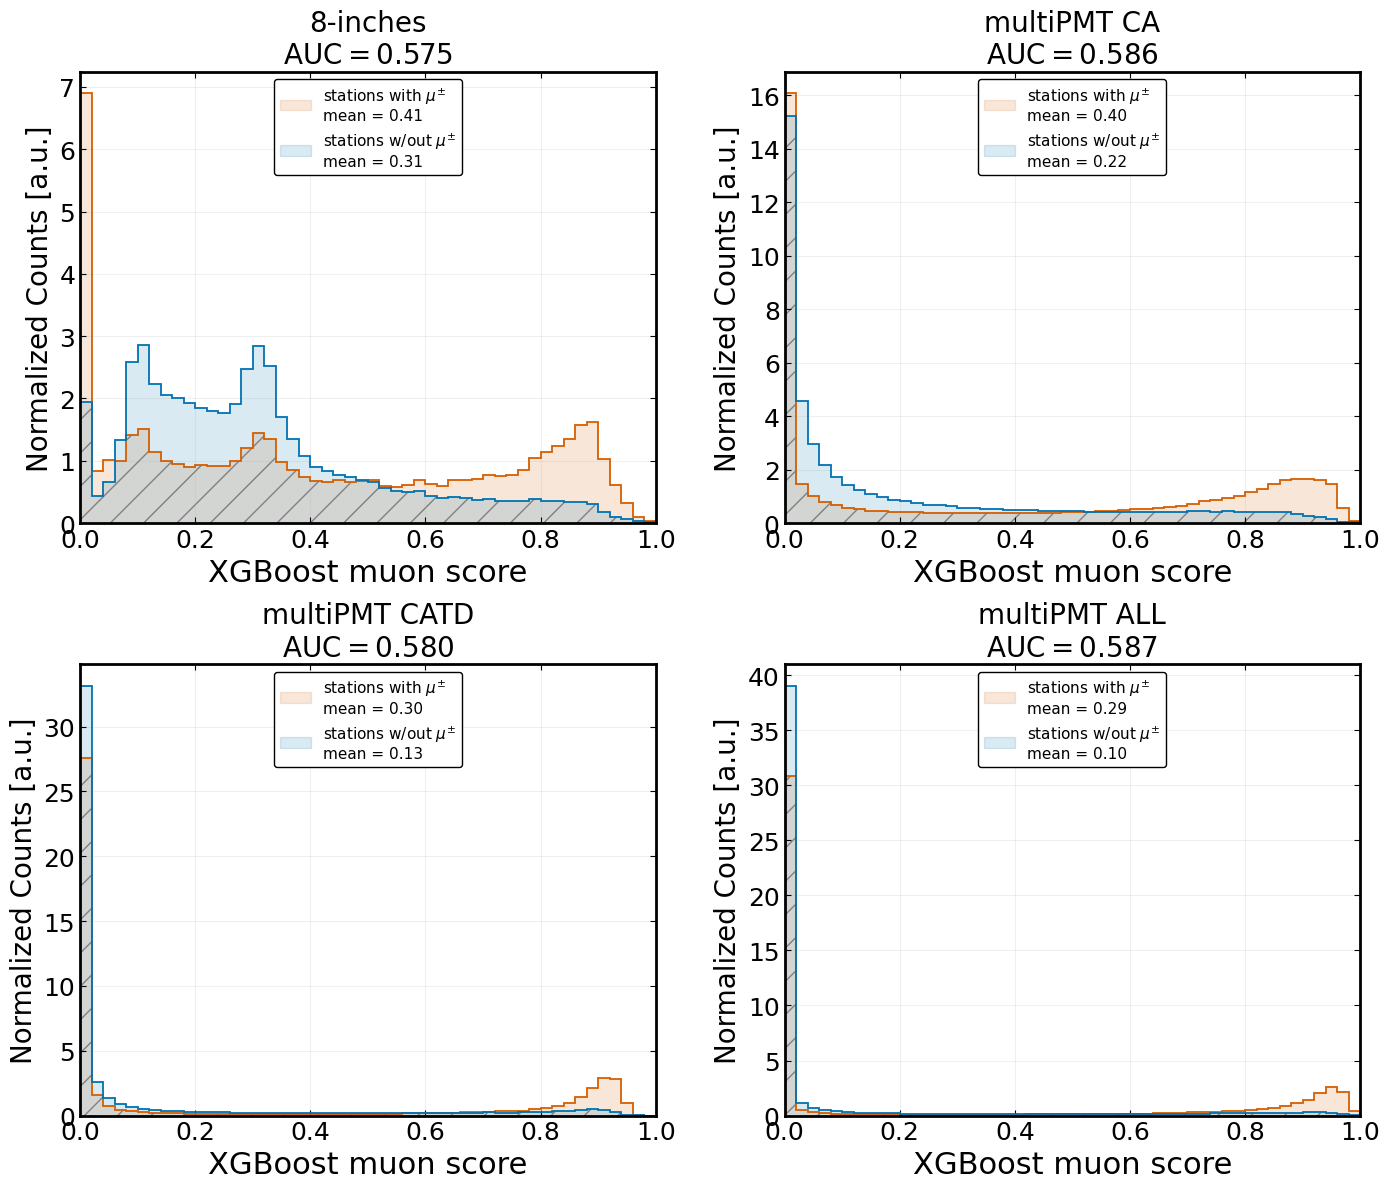

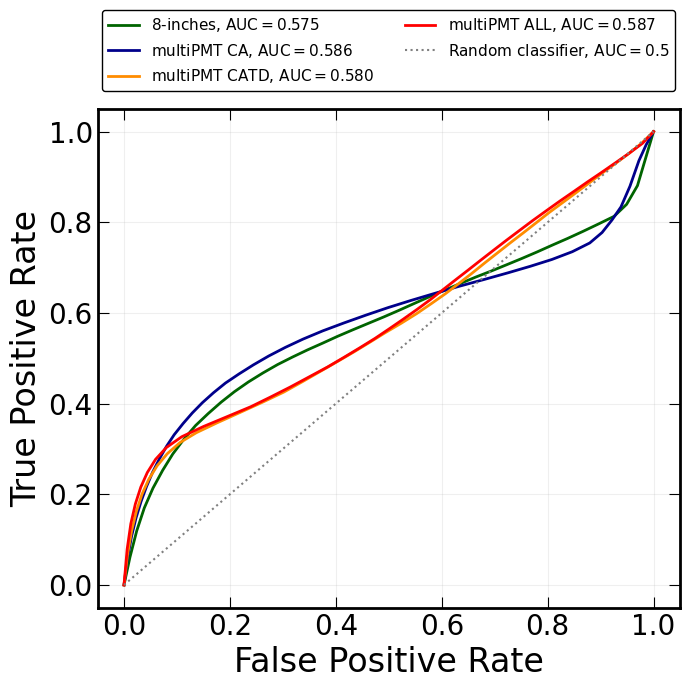

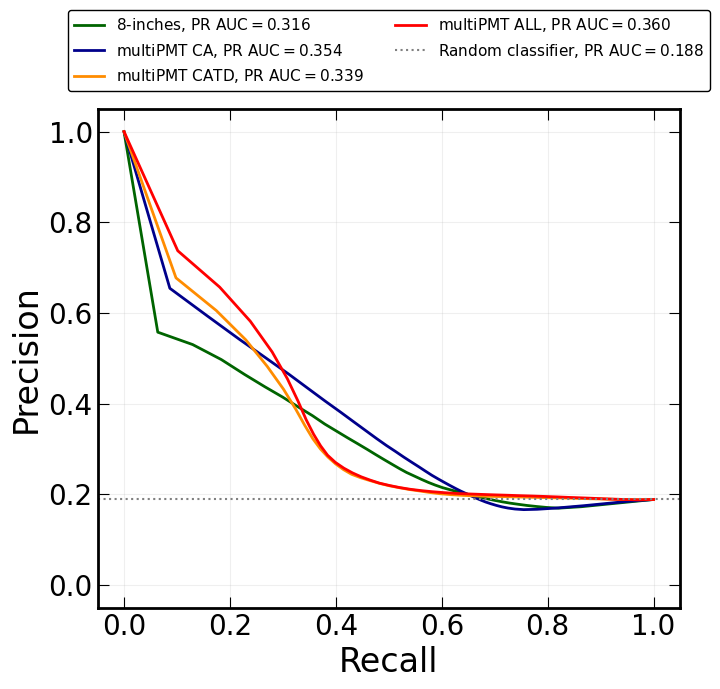

In [38]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.impute import SimpleImputer
from sklearn.metrics import auc, precision_recall_curve, roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier


def compute_promptness(df, sigma_t=0.2):

    t_min = pd.to_numeric(df["t_min"], errors="coerce").to_numpy(dtype=float)
    t_2min = pd.to_numeric(df["t_2min"], errors="coerce").to_numpy(dtype=float)
    t_3min = pd.to_numeric(df["t_3min"], errors="coerce").to_numpy(dtype=float)
    t_4min = pd.to_numeric(df["t_4min"], errors="coerce").to_numpy(dtype=float)
    t_5min = pd.to_numeric(df["t_5min"], errors="coerce").to_numpy(dtype=float)
    t_6min = pd.to_numeric(df["t_6min"], errors="coerce").to_numpy(dtype=float)
    t_7min = pd.to_numeric(df["t_7min"], errors="coerce").to_numpy(dtype=float)

    time_spread = np.nan_to_num((t_2min - t_min) / sigma_t, nan=0.0) + np.nan_to_num((t_3min - t_min) / sigma_t, nan=0.0) + np.nan_to_num((t_4min - t_min) / sigma_t, nan=0.0) + np.nan_to_num((t_5min - t_min) / sigma_t, nan=0.0) + np.nan_to_num((t_6min - t_min) / sigma_t, nan=0.0) + np.nan_to_num((t_7min - t_min) / sigma_t, nan=0.0)

    return np.log(np.maximum(time_spread + 1, 1e-12))


TEST_PROTONS_features_path = Path(f"{PROJECT_DIR}/{conf['feats_dir']}/{conf['array_dir']}/test_protons/{conf['params_dir']}/{conf['features_cut_dir']}/")

test_files = sorted(TEST_PROTONS_features_path.glob("*.parquet"))

print("External test directory:", TEST_PROTONS_features_path)
print("Number of test files:", len(test_files))

if not test_files:
    raise FileNotFoundError(f"No test Parquet files found in {TEST_PROTONS_features_path}")

df_external_test = pd.concat([pd.read_parquet(test_file) for test_file in test_files], ignore_index=True)

print("Test stations before selection:", len(df_external_test))

df_external_test = df_external_test[df_external_test["T_C"] >= conf["test_min_st_dist"]]
df_external_test = df_external_test[df_external_test["T_C"] <= conf["test_max_st_dist"]]
df_external_test = df_external_test[df_external_test["total_pe"] >= conf["test_pe_min"]]
df_external_test = df_external_test.reset_index(drop=True)

df_external_test["promptness"] = compute_promptness(df_external_test, sigma_t=0.2)

print("Test stations after selection:", len(df_external_test))
print("\nExternal-test class counts:")
print(df_external_test["IsThereMuon"].value_counts())
print("\nExternal-test class fractions:")
print(df_external_test["IsThereMuon"].value_counts(normalize=True))

y_train_full = df_common["IsThereMuon"].to_numpy(dtype=int)
y_external_test = df_external_test["IsThereMuon"].to_numpy(dtype=int)

if len(np.unique(y_external_test)) != 2:
    raise ValueError("The external test dataset must contain both classes.")

external_pr_baseline = np.mean(y_external_test == 1)

print(f"\nExternal-test PR-AUC baseline = {external_pr_baseline:.4f}")

external_results = {}
external_summary = []
final_xgb_models = {}

for model_name, previous_result in xgb_results.items():

    features = previous_result["features"]
    best_params = previous_result["best_params"]

    missing_train_features = [feature for feature in features if feature not in df_common.columns]
    missing_test_features = [feature for feature in features if feature not in df_external_test.columns]

    if missing_train_features:
        raise KeyError(f"{model_name} is missing training features: {missing_train_features}")

    if missing_test_features:
        raise KeyError(f"{model_name} is missing test features: {missing_test_features}")

    X_train_full = df_common[features].replace([np.inf, -np.inf], np.nan)
    X_external_test = df_external_test[features].replace([np.inf, -np.inf], np.nan)

    final_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("model", XGBClassifier(**best_params))])

    final_pipeline.fit(X_train_full, y_train_full)

    external_score = final_pipeline.predict_proba(X_external_test)[:, 1]

    roc_auc_value = roc_auc_score(y_external_test, external_score)
    fpr, tpr, roc_thresholds = roc_curve(y_external_test, external_score)

    precision, recall, pr_thresholds = precision_recall_curve(y_external_test, external_score)
    pr_auc_value = auc(recall, precision)

    final_xgb_models[model_name] = final_pipeline

    external_results[model_name] = {"model": final_pipeline, "features": features, "score": external_score, "roc_auc": roc_auc_value, "pr_auc": pr_auc_value, "fpr": fpr, "tpr": tpr, "roc_thresholds": roc_thresholds, "precision": precision, "recall": recall, "pr_thresholds": pr_thresholds}

    external_summary.append({"model": model_name, "n_features": len(features), "n_train": len(X_train_full), "n_test": len(X_external_test), "roc_auc": roc_auc_value, "pr_auc": pr_auc_value})

    print(f"\n{model_name}")
    print(f"External-test ROC-AUC = {roc_auc_value:.4f}")
    print(f"External-test PR-AUC = {pr_auc_value:.4f}")

external_summary = pd.DataFrame(external_summary)

print("\nExternal-test comparison:")
display(external_summary)


mu_color = "#D55E00"
nomu_color = "#0072B2"

n_models = len(external_results)
n_columns = 2
n_rows = math.ceil(n_models / n_columns)

fig, axes = plt.subplots(n_rows, n_columns, figsize=(14, 6 * n_rows))

axes = np.atleast_1d(axes).flatten()

for ax, (model_name, result) in zip(axes, external_results.items()):

    external_score = np.asarray(result["score"])

    score_mu = external_score[y_external_test == 1]
    score_nomu = external_score[y_external_test == 0]

    score_mu = score_mu[np.isfinite(score_mu)]
    score_nomu = score_nomu[np.isfinite(score_nomu)]

    bins = 50
    range_hist = (0, 1)

    counts_mu, bin_edges = np.histogram(score_mu, bins=bins, range=range_hist, density=True)
    counts_nomu, _ = np.histogram(score_nomu, bins=bins, range=range_hist, density=True)

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]
    overlap = np.minimum(counts_mu, counts_nomu)

    mean_mu = np.mean(score_mu)
    mean_nomu = np.mean(score_nomu)

    ax.hist(score_mu, density=True, bins=bins, range=range_hist, histtype="stepfilled", color=mu_color, alpha=0.15)
    ax.hist(score_mu, density=True, bins=bins, range=range_hist, histtype="step", color=mu_color, linewidth=1.3)

    ax.hist(score_nomu, density=True, bins=bins, range=range_hist, histtype="stepfilled", color=nomu_color, alpha=0.15)
    ax.hist(score_nomu, density=True, bins=bins, range=range_hist, histtype="step", color=nomu_color, linewidth=1.3)

    ax.bar(bin_centers, overlap, width=bin_width, color="none", edgecolor="gray", hatch="/", linewidth=0)

    handles = [Rectangle((0, 0), 1, 1, facecolor=mu_color, edgecolor=mu_color, linewidth=1, alpha=0.15), Rectangle((0, 0), 1, 1, facecolor=nomu_color, edgecolor=nomu_color, linewidth=1, alpha=0.15)]

    labels = [rf"stations with $\mu^{{\pm}}$" + "\n" + rf"mean = {mean_mu:.2f}", rf"stations w/out $\mu^{{\pm}}$" + "\n" + rf"mean = {mean_nomu:.2f}"]

    ax.set_title(model_name.replace("_", " ") + "\n" + rf"$\mathrm{{AUC}}={result['roc_auc']:.3f}$", fontsize=20)
    ax.set_xlabel("XGBoost muon score", fontsize=22)
    ax.set_ylabel("Normalized Counts [a.u.]", fontsize=20)

    ax.set_xlim(range_hist)

    ax.tick_params(axis="both", which="major", direction="in", top=True, right=True, labelsize=18, length=4)
    ax.minorticks_off()
    ax.grid(True, alpha=0.2)

    for spine in ax.spines.values():
        spine.set_linewidth(2)

    ax.legend(handles=handles, labels=labels, loc="upper center", edgecolor="black", facecolor="white", framealpha=1.0, fontsize=11)

for ax in axes[n_models:]:
    ax.set_axis_off()

plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 6))

colors = ["darkgreen", "darkblue", "darkorange", "red"]
linestyles = ["-", "-", "-", "-"]

for (model_name, result), color, linestyle in zip(external_results.items(), colors, linestyles):

    fpr = np.asarray(result["fpr"])
    tpr = np.asarray(result["tpr"])
    roc_auc_value = result["roc_auc"]

    n_points = 40
    plot_indices = np.unique(np.linspace(0, len(fpr) - 1, min(n_points, len(fpr)), dtype=int))

    plt.plot(fpr[plot_indices], tpr[plot_indices], color=color, linestyle=linestyle, linewidth=2, label=rf"{model_name.replace('_', ' ')}, $\mathrm{{AUC}}={roc_auc_value:.3f}$")

plt.plot([0, 1], [0, 1], color="gray", linestyle=":", linewidth=1.5, label=r"Random classifier, $\mathrm{AUC}=0.5$")

plt.xlabel("False Positive Rate", fontsize=24)
plt.ylabel("True Positive Rate", fontsize=24)

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

plt.tick_params(axis="both", which="major", direction="in", top=True, right=True, labelsize=20, length=8)
plt.minorticks_off()
plt.grid(True, alpha=0.2)

for spine in plt.gca().spines.values():
    spine.set_linewidth(2)

plt.tight_layout()

plt.legend(frameon=True, fontsize=11, facecolor="white", framealpha=1.0, edgecolor="black", loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2)

plt.show()


plt.figure(figsize=(7, 6))

for (model_name, result), color, linestyle in zip(external_results.items(), colors, linestyles):

    precision = np.asarray(result["precision"])
    recall = np.asarray(result["recall"])
    pr_auc_value = result["pr_auc"]

    n_points = 40
    plot_indices = np.unique(np.linspace(0, len(recall) - 1, min(n_points, len(recall)), dtype=int))

    plt.plot(recall[plot_indices], precision[plot_indices], color=color, linestyle=linestyle, linewidth=2, label=rf"{model_name.replace('_', ' ')}, $\mathrm{{PR\ AUC}}={pr_auc_value:.3f}$")

plt.axhline(external_pr_baseline, color="gray", linestyle=":", linewidth=1.5, label=rf"Random classifier, $\mathrm{{PR\ AUC}}={external_pr_baseline:.3f}$")

plt.xlabel("Recall", fontsize=24)
plt.ylabel("Precision", fontsize=24)

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

plt.tick_params(axis="both", which="major", direction="in", top=True, right=True, labelsize=20, length=8)
plt.minorticks_off()
plt.grid(True, alpha=0.2)

for spine in plt.gca().spines.values():
    spine.set_linewidth(2)

plt.tight_layout()

plt.legend(frameon=True, fontsize=11, facecolor="white", framealpha=1.0, edgecolor="black", loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2)

plt.show()

SMONLY test directory: /home/grieco/SWGO_Soft/git_GH_multiPMT/working_branch/multiPMT_GammaHadron_ML/dfs_feats/mPMT_HAWCSim_array/test_protons_SMONLY/100300TeV_030deg_4FF_180R175h_Black/NoneMHz_ADC_13petrain_13petest_500ns
Number of SMONLY test files: 4153
SMONLY test stations before selection: 1026120
SMONLY test stations after selection: 1021717

SMONLY class counts:
IsThereMuon
0    969315
1     52402
Name: count, dtype: int64

SMONLY class fractions:
IsThereMuon
0    0.948712
1    0.051288
Name: proportion, dtype: float64

SMONLY PR-AUC baseline = 0.0513

8-inches
SMONLY ROC-AUC = 0.9308
SMONLY PR-AUC = 0.4096

multiPMT_CA
SMONLY ROC-AUC = 0.9405
SMONLY PR-AUC = 0.4618

multiPMT_CATD
SMONLY ROC-AUC = 0.9628
SMONLY PR-AUC = 0.5338

multiPMT_ALL
SMONLY ROC-AUC = 0.9704
SMONLY PR-AUC = 0.5998

SMONLY comparison:


,model,n_features,n_train,n_test,mean_score,median_score,roc_auc,pr_auc
0,8-inches,3,444664,1021717,0.333178,0.287670,0.930830,0.409638
1,multiPMT_CA,10,444664,1021717,0.247845,0.095872,0.940467,0.461817
2,multiPMT_CATD,25,444664,1021717,0.165590,0.005523,0.962849,0.533829
3,multiPMT_ALL,46,444664,1021717,0.134192,0.000054,0.970372,0.599841


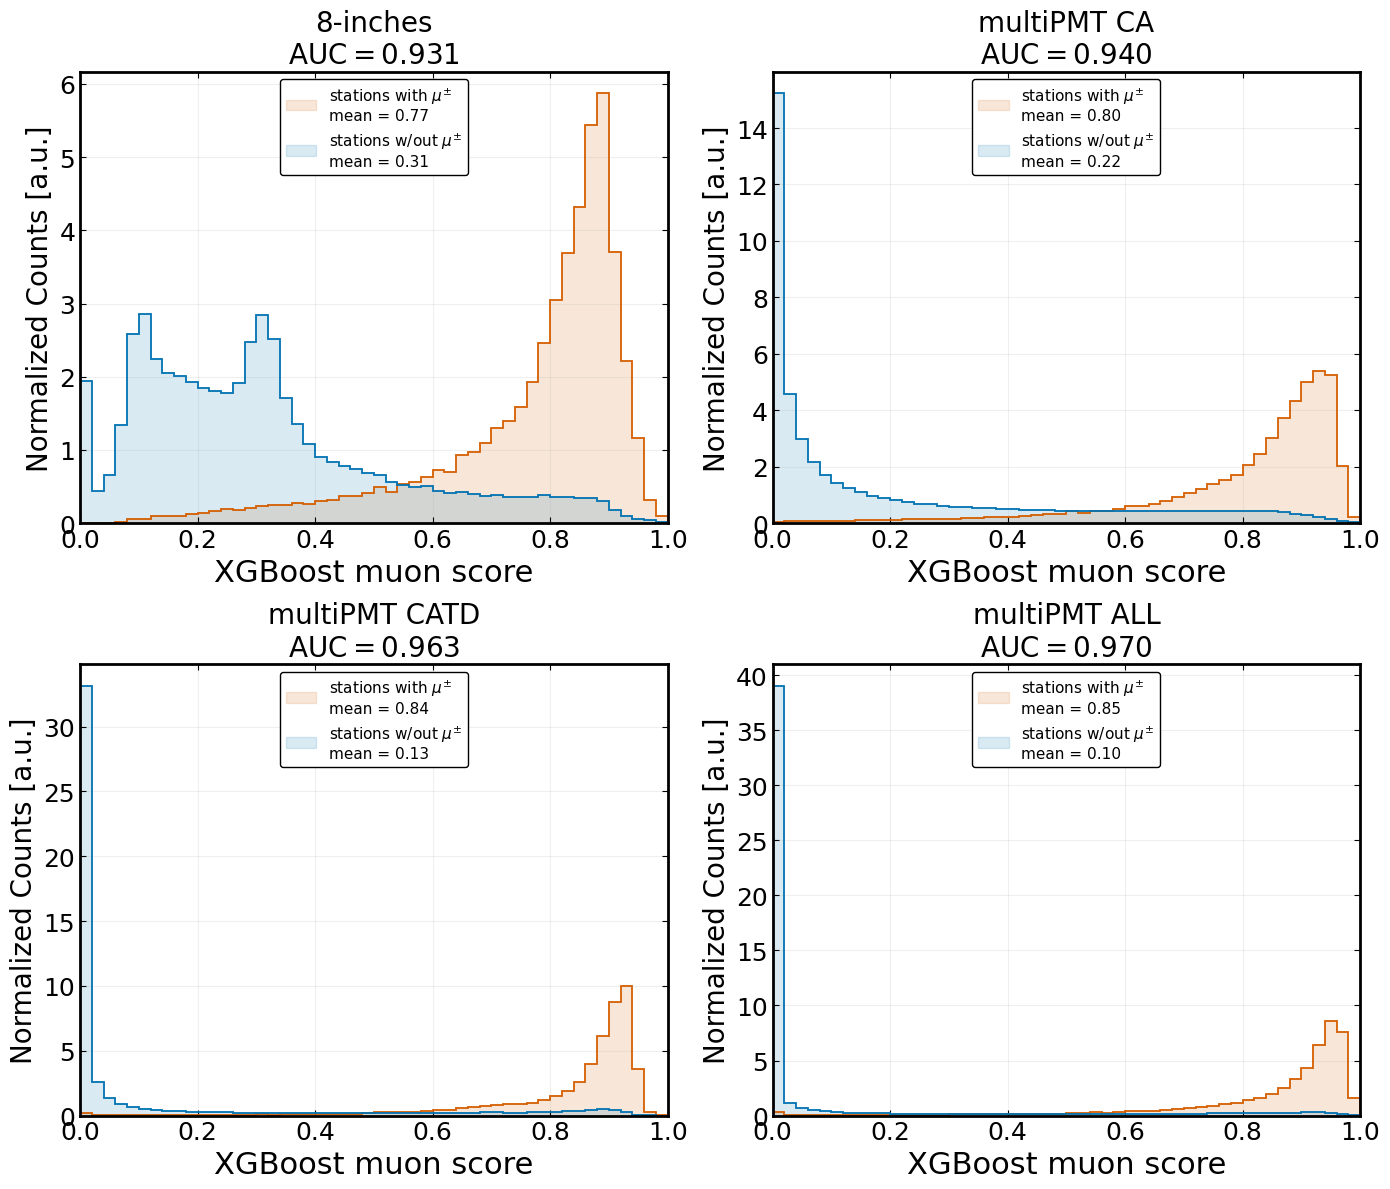

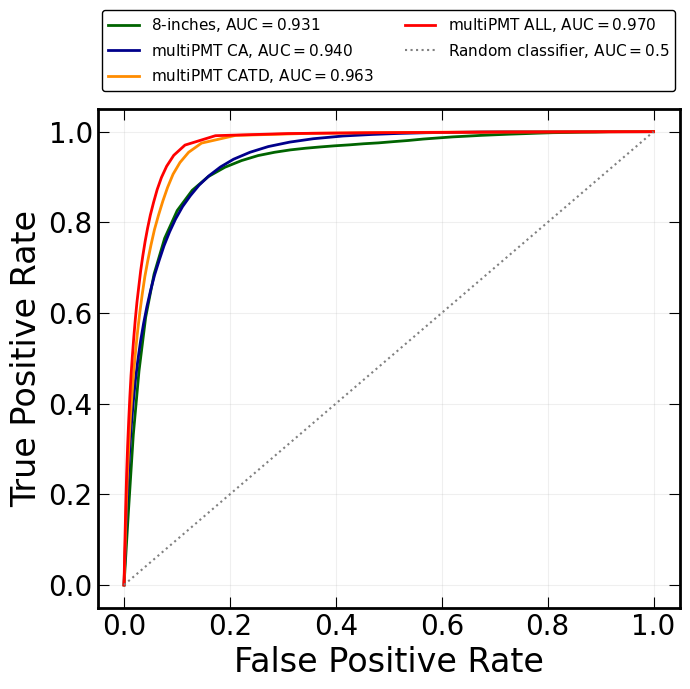

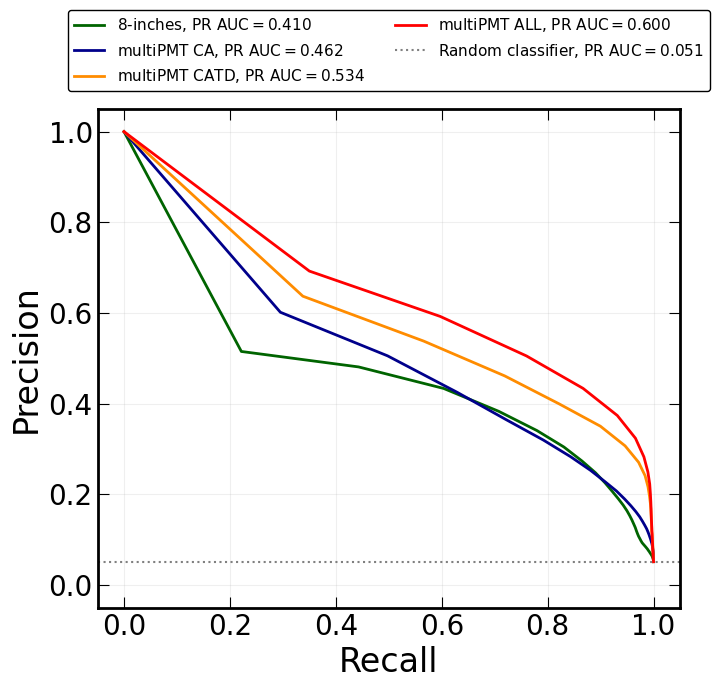

In [39]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.impute import SimpleImputer
from sklearn.metrics import auc, precision_recall_curve, roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier


TEST_PROTONS_SMONLY_features_path = Path(f"{PROJECT_DIR}/{conf['feats_dir']}/{conf['array_dir']}/test_protons_SMONLY/{conf['params_dir']}/{conf['features_cut_dir']}/")

smonly_test_files = sorted(TEST_PROTONS_SMONLY_features_path.glob("*.parquet"))

print("SMONLY test directory:", TEST_PROTONS_SMONLY_features_path)
print("Number of SMONLY test files:", len(smonly_test_files))

if not smonly_test_files:
    raise FileNotFoundError(f"No SMONLY test Parquet files found in {TEST_PROTONS_SMONLY_features_path}")

df_smonly_test = pd.concat([pd.read_parquet(test_file) for test_file in smonly_test_files], ignore_index=True)

print("SMONLY test stations before selection:", len(df_smonly_test))

df_smonly_test = df_smonly_test[df_smonly_test["T_C"] >= conf["test_min_st_dist"]]
df_smonly_test = df_smonly_test[df_smonly_test["T_C"] <= conf["test_max_st_dist"]]
df_smonly_test = df_smonly_test[df_smonly_test["total_pe"] >= conf["test_pe_min"]]
df_smonly_test = df_smonly_test.reset_index(drop=True)

df_smonly_test["promptness"] = compute_promptness(df_smonly_test, sigma_t=0.2)

print("SMONLY test stations after selection:", len(df_smonly_test))
print("\nSMONLY class counts:")
print(df_smonly_test["IsThereMuon"].value_counts())
print("\nSMONLY class fractions:")
print(df_smonly_test["IsThereMuon"].value_counts(normalize=True))

y_train_full = df_common["IsThereMuon"].to_numpy(dtype=int)
y_smonly_test = df_smonly_test["IsThereMuon"].to_numpy(dtype=int)

two_classes_present = len(np.unique(y_smonly_test)) == 2

if two_classes_present:
    smonly_pr_baseline = np.mean(y_smonly_test == 1)
    print(f"\nSMONLY PR-AUC baseline = {smonly_pr_baseline:.4f}")
else:
    smonly_pr_baseline = np.nan
    print("\nOnly one class is present: ROC-AUC and PR-AUC cannot be calculated.")

smonly_results = {}
smonly_summary = []
smonly_final_models = {}

for model_name, previous_result in xgb_results.items():

    features = previous_result["features"]
    best_params = previous_result["best_params"]

    missing_features = [feature for feature in features if feature not in df_smonly_test.columns]

    if missing_features:
        raise KeyError(f"{model_name} is missing SMONLY features: {missing_features}")

    X_train_full = df_common[features].replace([np.inf, -np.inf], np.nan)
    X_smonly_test = df_smonly_test[features].replace([np.inf, -np.inf], np.nan)

    final_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("model", XGBClassifier(**best_params))])

    final_pipeline.fit(X_train_full, y_train_full)

    smonly_score = final_pipeline.predict_proba(X_smonly_test)[:, 1]

    result = {"model": final_pipeline, "features": features, "score": smonly_score}

    summary_row = {"model": model_name, "n_features": len(features), "n_train": len(X_train_full), "n_test": len(X_smonly_test), "mean_score": np.mean(smonly_score), "median_score": np.median(smonly_score)}

    if two_classes_present:

        roc_auc_value = roc_auc_score(y_smonly_test, smonly_score)
        fpr, tpr, roc_thresholds = roc_curve(y_smonly_test, smonly_score)

        precision, recall, pr_thresholds = precision_recall_curve(y_smonly_test, smonly_score)
        pr_auc_value = auc(recall, precision)

        result.update({"roc_auc": roc_auc_value, "pr_auc": pr_auc_value, "fpr": fpr, "tpr": tpr, "roc_thresholds": roc_thresholds, "precision": precision, "recall": recall, "pr_thresholds": pr_thresholds})

        summary_row.update({"roc_auc": roc_auc_value, "pr_auc": pr_auc_value})

        print(f"\n{model_name}")
        print(f"SMONLY ROC-AUC = {roc_auc_value:.4f}")
        print(f"SMONLY PR-AUC = {pr_auc_value:.4f}")

    else:

        summary_row.update({"roc_auc": np.nan, "pr_auc": np.nan})

        print(f"\n{model_name}")
        print(f"Mean SMONLY score = {np.mean(smonly_score):.4f}")
        print(f"Median SMONLY score = {np.median(smonly_score):.4f}")
        print(f"Fraction with score >= 0.5 = {np.mean(smonly_score >= 0.5):.4f}")
        print(f"Fraction with score >= 0.8 = {np.mean(smonly_score >= 0.8):.4f}")
        print(f"Fraction with score >= 0.9 = {np.mean(smonly_score >= 0.9):.4f}")

    smonly_final_models[model_name] = final_pipeline
    smonly_results[model_name] = result
    smonly_summary.append(summary_row)

smonly_summary = pd.DataFrame(smonly_summary)

print("\nSMONLY comparison:")
display(smonly_summary)


mu_color = "#D55E00"
nomu_color = "#0072B2"

n_models = len(smonly_results)
n_columns = 2
n_rows = math.ceil(n_models / n_columns)

fig, axes = plt.subplots(n_rows, n_columns, figsize=(14, 6 * n_rows))

axes = np.atleast_1d(axes).flatten()

for ax, (model_name, result) in zip(axes, smonly_results.items()):

    smonly_score = np.asarray(result["score"])

    if two_classes_present:

        score_mu = smonly_score[y_smonly_test == 1]
        score_nomu = smonly_score[y_smonly_test == 0]

        mean_mu = np.mean(score_mu)
        mean_nomu = np.mean(score_nomu)

        ax.hist(score_mu, density=True, bins=50, range=(0, 1), histtype="stepfilled", color=mu_color, alpha=0.15)
        ax.hist(score_mu, density=True, bins=50, range=(0, 1), histtype="step", color=mu_color, linewidth=1.3)

        ax.hist(score_nomu, density=True, bins=50, range=(0, 1), histtype="stepfilled", color=nomu_color, alpha=0.15)
        ax.hist(score_nomu, density=True, bins=50, range=(0, 1), histtype="step", color=nomu_color, linewidth=1.3)

        handles = [Rectangle((0, 0), 1, 1, facecolor=mu_color, edgecolor=mu_color, alpha=0.15), Rectangle((0, 0), 1, 1, facecolor=nomu_color, edgecolor=nomu_color, alpha=0.15)]
        labels = [rf"stations with $\mu^{{\pm}}$" + "\n" + rf"mean = {mean_mu:.2f}", rf"stations w/out $\mu^{{\pm}}$" + "\n" + rf"mean = {mean_nomu:.2f}"]

        ax.set_title(model_name.replace("_", " ") + "\n" + rf"$\mathrm{{AUC}}={result['roc_auc']:.3f}$", fontsize=20)

    else:

        mean_score = np.mean(smonly_score)

        ax.hist(smonly_score, density=True, bins=50, range=(0, 1), histtype="stepfilled", color=mu_color, alpha=0.15)
        ax.hist(smonly_score, density=True, bins=50, range=(0, 1), histtype="step", color=mu_color, linewidth=1.3)

        handles = [Rectangle((0, 0), 1, 1, facecolor=mu_color, edgecolor=mu_color, alpha=0.15)]
        labels = [rf"single-$\mu^{{\pm}}$ stations" + "\n" + rf"mean = {mean_score:.2f}"]

        ax.set_title(model_name.replace("_", " "), fontsize=20)

    ax.set_xlabel("XGBoost muon score", fontsize=22)
    ax.set_ylabel("Normalized Counts [a.u.]", fontsize=20)
    ax.set_xlim(0, 1)

    ax.tick_params(axis="both", which="major", direction="in", top=True, right=True, labelsize=18, length=4)
    ax.minorticks_off()
    ax.grid(True, alpha=0.2)

    for spine in ax.spines.values():
        spine.set_linewidth(2)

    ax.legend(handles=handles, labels=labels, loc="upper center", edgecolor="black", facecolor="white", framealpha=1.0, fontsize=11)

for ax in axes[n_models:]:
    ax.set_axis_off()

plt.tight_layout()
plt.show()


if two_classes_present:

    plt.figure(figsize=(7, 6))

    colors = ["darkgreen", "darkblue", "darkorange", "red"]
    linestyles = ["-", "-", "-", "-"]

    for (model_name, result), color, linestyle in zip(smonly_results.items(), colors, linestyles):

        fpr = np.asarray(result["fpr"])
        tpr = np.asarray(result["tpr"])

        plot_indices = np.unique(np.linspace(0, len(fpr) - 1, min(40, len(fpr)), dtype=int))

        plt.plot(fpr[plot_indices], tpr[plot_indices], color=color, linestyle=linestyle, linewidth=2, label=rf"{model_name.replace('_', ' ')}, $\mathrm{{AUC}}={result['roc_auc']:.3f}$")

    plt.plot([0, 1], [0, 1], color="gray", linestyle=":", linewidth=1.5, label=r"Random classifier, $\mathrm{AUC}=0.5$")

    plt.xlabel("False Positive Rate", fontsize=24)
    plt.ylabel("True Positive Rate", fontsize=24)

    plt.xlim(-0.05, 1.05)
    plt.ylim(-0.05, 1.05)

    plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

    plt.tick_params(axis="both", which="major", direction="in", top=True, right=True, labelsize=20, length=8)
    plt.minorticks_off()
    plt.grid(True, alpha=0.2)

    for spine in plt.gca().spines.values():
        spine.set_linewidth(2)

    plt.tight_layout()

    plt.legend(frameon=True, fontsize=11, facecolor="white", framealpha=1.0, edgecolor="black", loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2)

    plt.show()


    plt.figure(figsize=(7, 6))

    for (model_name, result), color, linestyle in zip(smonly_results.items(), colors, linestyles):

        precision = np.asarray(result["precision"])
        recall = np.asarray(result["recall"])

        plot_indices = np.unique(np.linspace(0, len(recall) - 1, min(40, len(recall)), dtype=int))

        plt.plot(recall[plot_indices], precision[plot_indices], color=color, linestyle=linestyle, linewidth=2, label=rf"{model_name.replace('_', ' ')}, $\mathrm{{PR\ AUC}}={result['pr_auc']:.3f}$")

    plt.axhline(smonly_pr_baseline, color="gray", linestyle=":", linewidth=1.5, label=rf"Random classifier, $\mathrm{{PR\ AUC}}={smonly_pr_baseline:.3f}$")

    plt.xlabel("Recall", fontsize=24)
    plt.ylabel("Precision", fontsize=24)

    plt.xlim(-0.05, 1.05)
    plt.ylim(-0.05, 1.05)

    plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

    plt.tick_params(axis="both", which="major", direction="in", top=True, right=True, labelsize=20, length=8)
    plt.minorticks_off()
    plt.grid(True, alpha=0.2)

    for spine in plt.gca().spines.values():
        spine.set_linewidth(2)

    plt.tight_layout()

    plt.legend(frameon=True, fontsize=11, facecolor="white", framealpha=1.0, edgecolor="black", loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2)

    plt.show()